In [1]:
import rasterio
import numpy as np
from pathlib import Path

# ======== 1. Paths and settings ========
base_dir = Path(r"G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antractic_Max_NDVI_every_year\WHOLE MAP\LAND")

# Years
first_years = [2002, 2003, 2004, 2005, 2006]
last_years  = [2019, 2020, 2021, 2022, 2023]

# NDVI thresholds
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]

# Output directory
out_dir = Path(r"G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Greenness_Dynamics_2002_2006_vs_2019_2023")
out_dir.mkdir(exist_ok=True)


# ======== 2. Open one file to get shape & profile ========
example_year = first_years[0]
example_path = base_dir / f"NDVIMAX_00_LAND_{example_year}.tif"

with rasterio.open(example_path) as src0:
    profile = src0.profile
    height, width = src0.height, src0.width
    nodata_value = src0.nodata

# We will write categorical maps (0,1,2,3) as uint8
profile.update(dtype="uint8", count=1, nodata=0)


# ======== 3. Initialize presence masks for each threshold ========
# For each threshold, we keep:
#   presence_first[thr]: bool array, True if NDVI >= thr at least once in 2002–2006
#   presence_last[thr]:  bool array, True if NDVI >= thr at least once in 2019–2023
presence_first = {}
presence_last = {}

for thr in thresholds:
    presence_first[thr] = np.zeros((height, width), dtype=bool)
    presence_last[thr]  = np.zeros((height, width), dtype=bool)


# ======== 4. Accumulate greenness presence for first 5 years ========
for year in first_years:
    path = base_dir / f"NDVIMAX_00_LAND_{year}.tif"
    print(f"Reading first-period year {year}: {path}")
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")

        # Valid mask (exclude nodata)
        if nodata_value is not None:
            valid = arr != nodata_value
        else:
            valid = np.ones_like(arr, dtype=bool)

        for thr in thresholds:
            presence_first[thr] |= (arr >= thr) & valid


# ======== 5. Accumulate greenness presence for last 5 years ========
for year in last_years:
    path = base_dir / f"NDVIMAX_00_LAND_{year}.tif"
    print(f"Reading last-period year {year}: {path}")
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")

        # Valid mask (exclude nodata)
        if nodata_value is not None:
            valid = arr != nodata_value
        else:
            valid = np.ones_like(arr, dtype=bool)

        for thr in thresholds:
            presence_last[thr] |= (arr >= thr) & valid


# ======== 6. Build and save greenness dynamics maps for each threshold ========
for thr in thresholds:
    print(f"Creating dynamics map for threshold {thr} ...")

    first = presence_first[thr]
    last  = presence_last[thr]

    # Start with all zeros (0 = never green in either period / background)
    dynamics = np.zeros((height, width), dtype="uint8")

    # 1 = Stable greenness
    dynamics[(first & last)] = 1

    # 2 = New greenness (only in last period)
    dynamics[(~first & last)] = 2

    # 3 = Disappeared greenness (only in first period)
    dynamics[(first & ~last)] = 3

    # Optional: if you want to force nodata where no valid pixels at all:
    # you could build a "valid_any" mask across all years and set dynamics[~valid_any] = 0
    # For now we keep 0 as "no greenness / background".

    thr_int = int(round(thr * 100))  # e.g., 10, 15, 20...
    out_path = out_dir / f"GreennessDynamics_thr{thr_int:03d}_2002_2006_vs_2019_2023.tif"

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(dynamics, 1)

    print(f"  Saved: {out_path}")


Reading first-period year 2002: G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antractic_Max_NDVI_every_year\WHOLE MAP\LAND\NDVIMAX_00_LAND_2002.tif
Reading first-period year 2003: G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antractic_Max_NDVI_every_year\WHOLE MAP\LAND\NDVIMAX_00_LAND_2003.tif
Reading first-period year 2004: G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antractic_Max_NDVI_every_year\WHOLE MAP\LAND\NDVIMAX_00_LAND_2004.tif
Reading first-period year 2005: G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antractic_Max_NDVI_every_year\WHOLE MAP\LAND\NDVIMAX_00_LAND_2005.tif
Reading first-period year 2006: G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antractic_Max_NDVI_every_year\WHOLE MAP\LAND\NDVIMAX_00_LAND_2006.tif
Reading last-period year 2019: G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antractic_Max_NDVI_every_year\WHOLE MAP\LAND\NDVIMAX_00_LAND_2019.tif
Reading last-period year 2020: G:\Hangkai\Anttarctic 

In [3]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
import geopandas as gpd
from pathlib import Path

# ============================================================
# 1. Paths and settings
# ============================================================

# Folder where your greenness dynamics tifs live
dyn_dir = Path(
    r"G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Greenness_Dynamics_2002_2006_vs_2019_2023"
)

# Shapefiles for regions
shp_dir = Path(r"G:\Hangkai\Anttarctic Vegetation Dynamic\Shapefile")
shp_whole   = shp_dir / "whole_3031.shp"
shp_pen     = shp_dir / "Pennisula_regions.shp"
shp_central = shp_dir / "central_regions.shp"
shp_west    = shp_dir / "west_coasline.shp"

# NDVI thresholds (matching the files you already created)
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]

# Output CSV for stats
out_csv = dyn_dir / "GreennessDynamics_PanelE_stats_by_threshold.csv"


# ============================================================
# 2. Open one dynamics tif to get geometry / CRS / pixel area
# ============================================================

example_thr = thresholds[0]
thr_str = f"{int(round(example_thr * 100)):03d}"
example_path = dyn_dir / f"GreennessDynamics_thr{thr_str}_2002_2006_vs_2019_2023.tif"

with rasterio.open(example_path) as src0:
    height, width = src0.height, src0.width
    transform = src0.transform
    raster_crs = src0.crs
    nodata_val = src0.nodata

# Compute pixel area in km² from transform (safer than hard-coding 0.25)
pixel_area_km2 = abs(transform.a * transform.e) / 1e6
print("Pixel area (km²):", pixel_area_km2)


# ============================================================
# 3. Build region masks (True inside polygon) in raster grid
# ============================================================

def build_region_mask(shp_path):
    gdf = gpd.read_file(shp_path)
    if gdf.crs is None:
        raise ValueError(f"Shapefile has no CRS: {shp_path}")
    if gdf.crs != raster_crs:
        gdf = gdf.to_crs(raster_crs)
    geoms = list(gdf.geometry)
    mask = geometry_mask(
        geoms,
        transform=transform,
        out_shape=(height, width),
        invert=True  # True inside polygons
    )
    return mask

region_masks = {
    "whole":   build_region_mask(shp_whole),
    "pen":     build_region_mask(shp_pen),
    "central": build_region_mask(shp_central),
    "west":    build_region_mask(shp_west),
}

region_labels = {
    "whole":   "Whole Antarctica",
    "pen":     "Peninsula",
    "central": "Transantarctic Mountain",
    "west":    "East Coastline",
}


# ============================================================
# 4. Helper: read dynamics tif for a given threshold
#    (values: 0,1,2,3; nodata -> NaN)
# ============================================================

def read_dynamics(thr):
    thr_str = f"{int(round(thr * 100)):03d}"
    path = dyn_dir / f"GreennessDynamics_thr{thr_str}_2002_2006_vs_2019_2023.tif"
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr


# ============================================================
# 5. Loop thresholds × regions and compute Panel E-style stats
# ============================================================

rows = []

for thr in thresholds:
    dyn = read_dynamics(thr)

    for region_key, mask in region_masks.items():
        region_name = region_labels[region_key]

        # Restrict to region and valid pixels
        region_vals = dyn[mask]
        region_vals = region_vals[~np.isnan(region_vals)]

        # Counts for each class
        n_stable      = np.sum(region_vals == 1)
        n_new         = np.sum(region_vals == 2)
        n_disappeared = np.sum(region_vals == 3)

        area_stable      = n_stable * pixel_area_km2
        area_new         = n_new * pixel_area_km2
        area_disappeared = n_disappeared * pixel_area_km2

        rows.append({
            "threshold": thr,
            "region_key": region_key,
            "region_name": region_name,
            "category": "Stable",
            "class_value": 1,
            "n_pixels": int(n_stable),
            "area_km2": area_stable,
        })
        rows.append({
            "threshold": thr,
            "region_key": region_key,
            "region_name": region_name,
            "category": "New",
            "class_value": 2,
            "n_pixels": int(n_new),
            "area_km2": area_new,
        })
        rows.append({
            "threshold": thr,
            "region_key": region_key,
            "region_name": region_name,
            "category": "Disappeared",
            "class_value": 3,
            "n_pixels": int(n_disappeared),
            "area_km2": area_disappeared,
        })

# Build DataFrame
stats_df = pd.DataFrame(rows)

print("\nFirst few rows:")
print(stats_df.head())

print("\nSummary (area km²) by threshold × region × category:")
print(
    stats_df.pivot_table(
        index=["threshold", "region_name"],
        columns="category",
        values="area_km2",
        aggfunc="sum"
    )
)

# Save to CSV
stats_df.to_csv(out_csv, index=False)
print(f"\nSaved stats to: {out_csv}")

Pixel area (km²): 0.25

First few rows:
   threshold region_key       region_name     category  class_value  n_pixels  \
0        0.1      whole  Whole Antarctica       Stable            1    108606   
1        0.1      whole  Whole Antarctica          New            2    265342   
2        0.1      whole  Whole Antarctica  Disappeared            3    252256   
3        0.1        pen         Peninsula       Stable            1     17469   
4        0.1        pen         Peninsula          New            2     42818   

   area_km2  
0  27151.50  
1  66335.50  
2  63064.00  
3   4367.25  
4  10704.50  

Summary (area km²) by threshold × region × category:
category                           Disappeared       New    Stable
threshold region_name                                             
0.10      East Coastline               1886.25   1605.25   1049.25
          Peninsula                    6890.75  10704.50   4367.25
          Transantarctic Mountain     43949.25  44950.75   9361.75


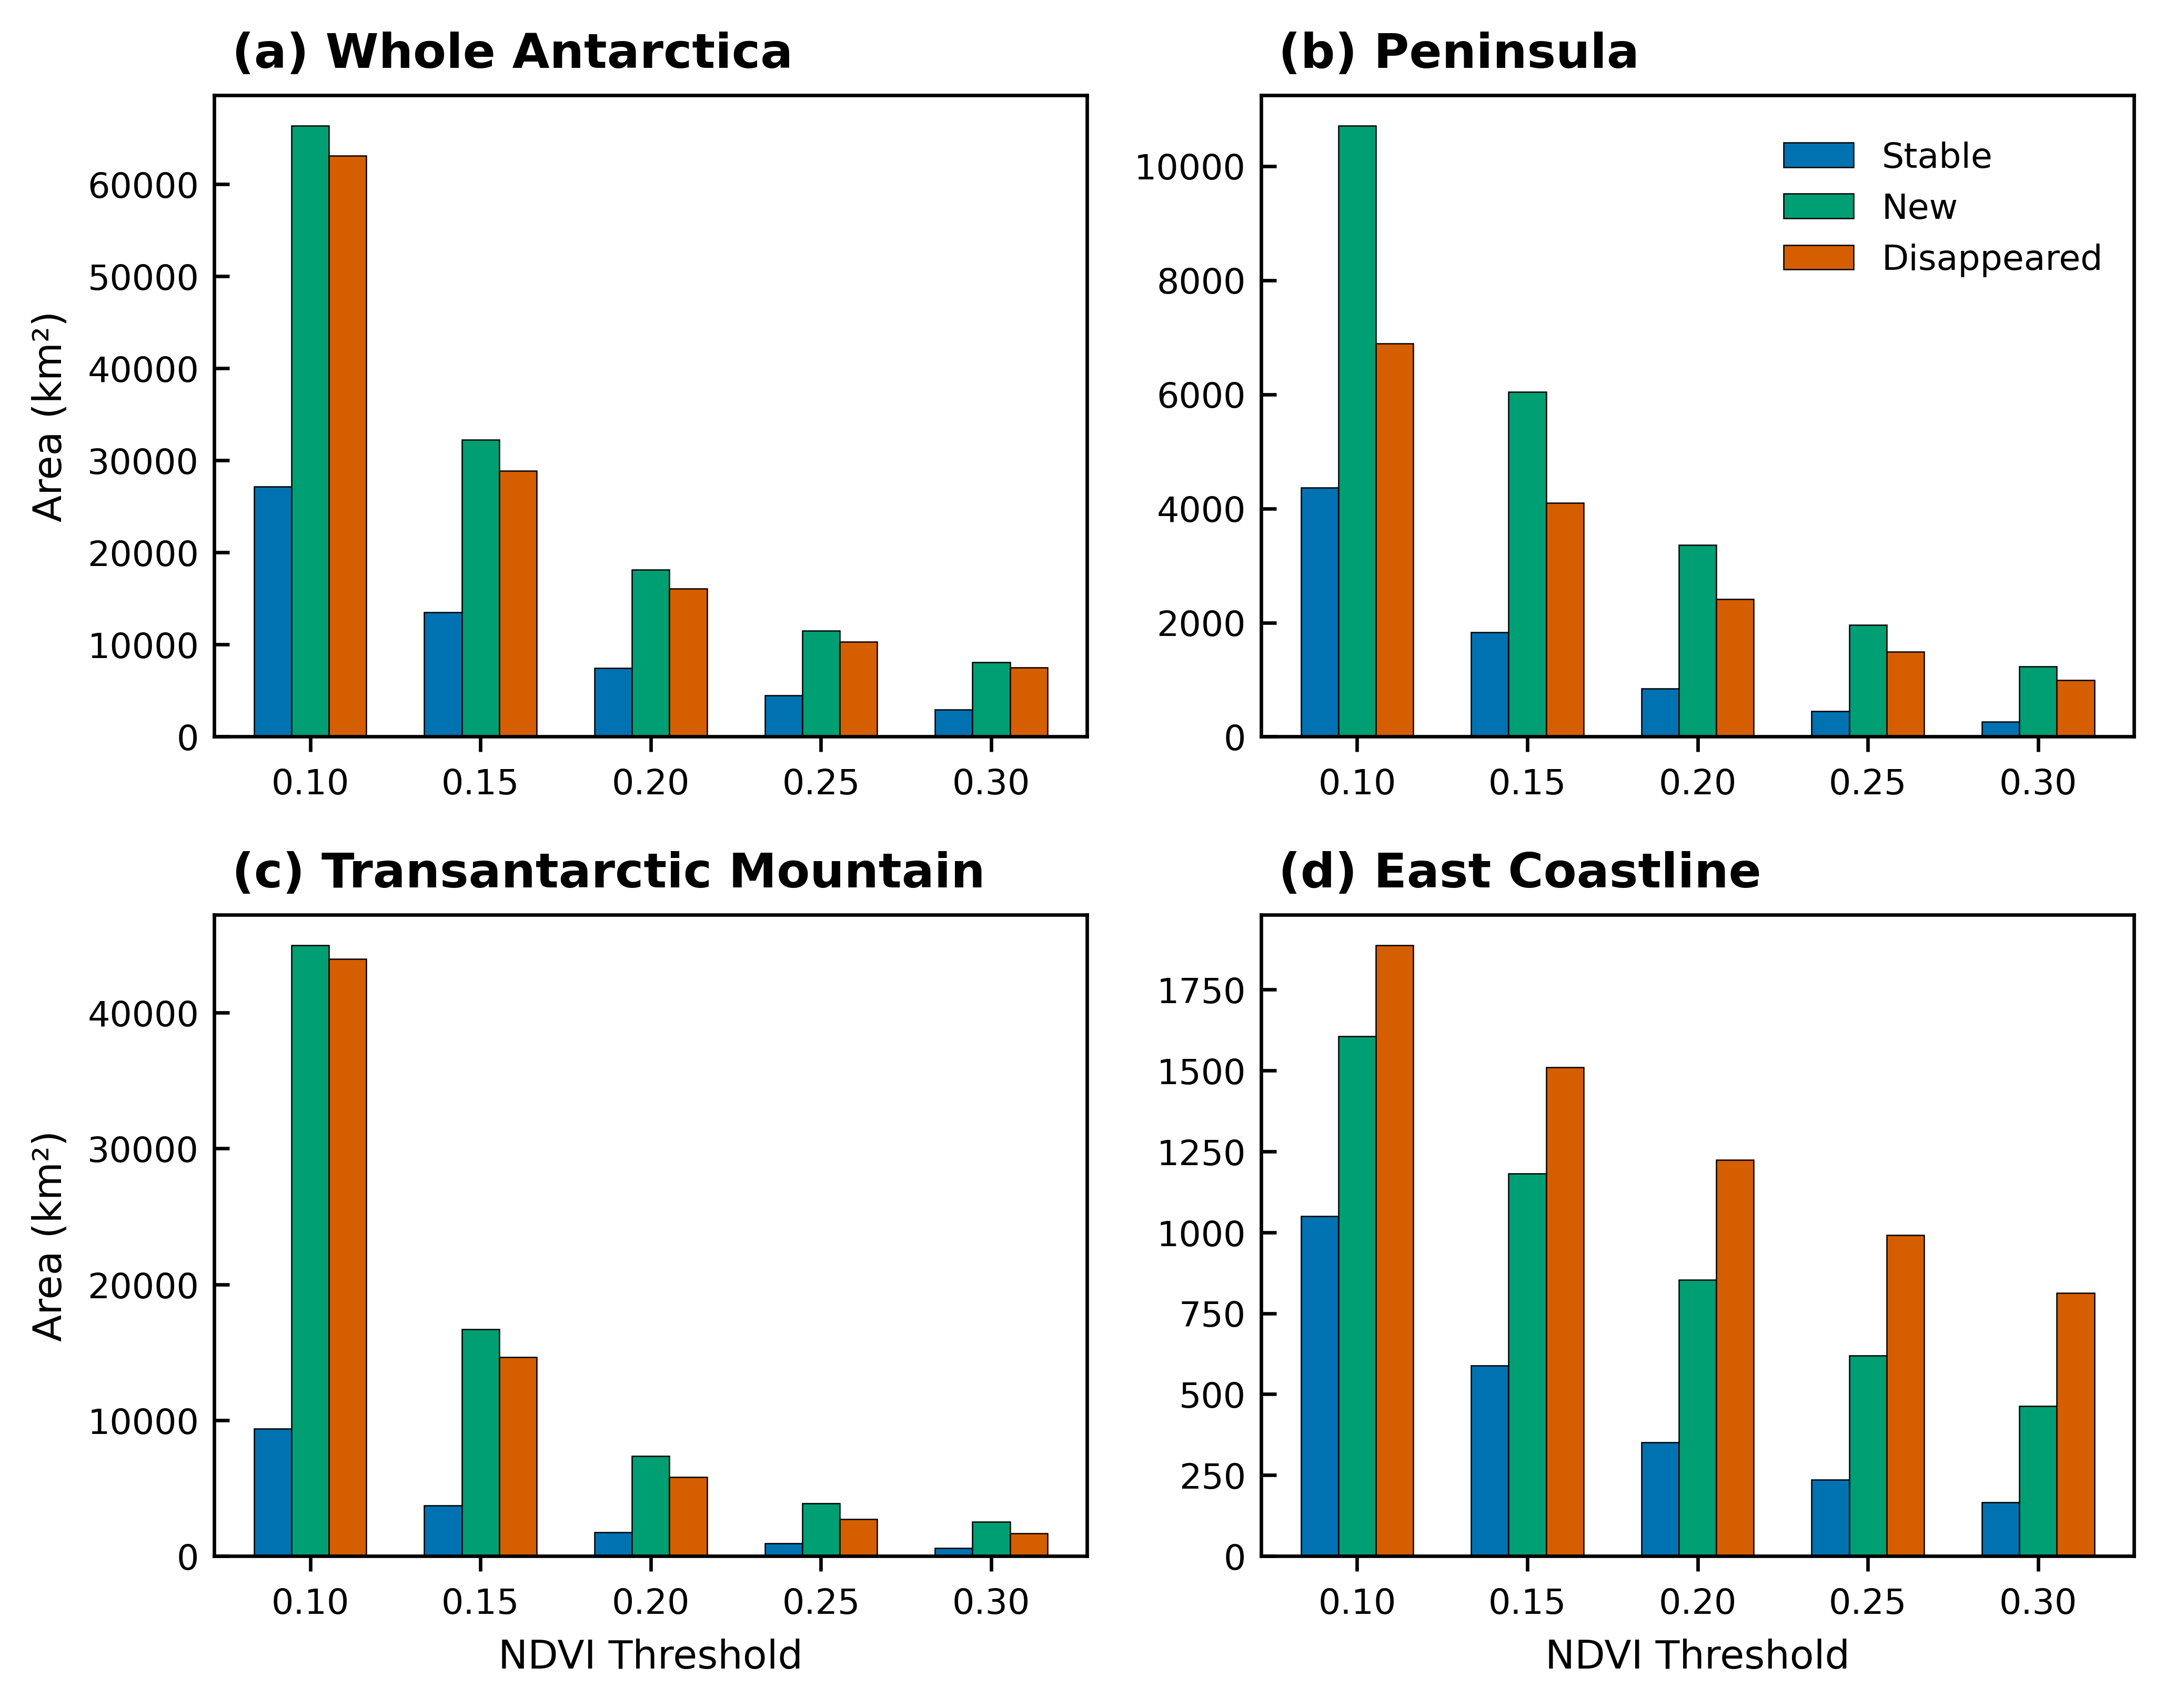

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. Read CSV
# ============================================================

csv_path = Path(
    r"G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Greenness_Dynamics_2002_2006_vs_2019_2023\GreennessDynamics_PanelE_stats_by_threshold.csv"
)

df = pd.read_csv(csv_path)

#print(df.head())  # optional to check structure


# ============================================================
# 2. Visualization parameters
# ============================================================
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

categories = ["Stable", "New", "Disappeared"]
colors = {
    "Stable":      "#0072B2",  # blue
    "New":         "#009E73",  # bluish green
    "Disappeared": "#D55E00",  # vermillion / orange
}
region_order = [
    "Whole Antarctica",
    "Peninsula",
    "Transantarctic Mountain",
    "East Coastline",
]

thresholds = sorted(df["threshold"].unique())
x = np.arange(len(thresholds))
bar_width = 0.22


# ============================================================
# 3. Create figure with 2x2 subplots (like original)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(8, 6), dpi=600, sharey=False)
axes = axes.ravel()

for idx, region_name in enumerate(region_order):
    ax = axes[idx]
    # --- PANEL LABEL ---
    ax.text(
        0.02, 1.1,                 # position (fraction of axes)
        panel_labels[idx] + " " + region_name, 
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
        ha="left"
    )

    sub = df[df["region_name"] == region_name]

    for j, cat in enumerate(categories):
        vals = []
        for thr in thresholds:
            v = sub[(sub["category"] == cat) & (sub["threshold"] == thr)]["area_km2"].values
            vals.append(v[0] if len(v) > 0 else np.nan)

        offset = (j - 1) * bar_width  # -1,0,+1
        ax.bar(
            x + offset,
            vals,
            width=bar_width,
            color=colors[cat],
            edgecolor="k",
            linewidth=0.3,
            label=cat if idx == 0 else ""
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"{thr:.2f}" for thr in thresholds], fontsize=8)

    if idx % 2 == 0:
        ax.set_ylabel("Area (km²)", fontsize=9)
    if idx >= 2:
        ax.set_xlabel("NDVI Threshold", fontsize=9)

    ax.tick_params(axis="y", labelsize=8, direction="in")


# ============================================================
# 4. Legend + Layout
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(0.73, 0.83),   # x, y in figure coordinates
    frameon=False,
    fontsize=8
)
fig.tight_layout(rect=[0.03, 0.03, 0.90, 0.95])
plt.savefig(r"C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\R1_Nature\Supplementary_Information\High_Resolution_Figures\SM_Sensitivity_New_Stable_Disappeared_Greenness_of_Hot_Spot_Region.png",
             dpi=600, bbox_inches="tight")
plt.show()